# Oil Is Equity in a Mirror 🪞
### In stocks, the storm comes after the fall. In oil, they say, it comes after the rally. Does it?

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Mirror?: Busted](https://img.shields.io/badge/Mirror%3F-Busted-8b949e?style=flat-square)

> **In one sentence:** on 1986-2018 WTI spot, oil is not equity in a mirror but a fainter
> copy — its volatility also rises more after falls (GJR t = -2.6), a tilt
> that appeared after 2008 — and a volatility-target overlay does not pay on the oil tape
> (net Sharpe gain -0.08), which is a spot price you could not hold anyway.

> 📓 **This is the plain-language layer.** The GARCH fits, Newey-West errors, the
> rolling windows and the bootstrap intervals are in
> **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**. The fingerprinted run is
> [docs/results.md](../docs/results.md).
>
> ⚠️ **Not investment advice.** Every chart below is computed by the code beside it, from
> real tapes frozen inside the `arch` Python package.

In [1]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
warnings.filterwarnings("ignore")
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 90
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
OIL, EQ, NULL = "#eb6834", "#2a78d6", "#8b949e"     # oil = orange, equity = blue
from mirrorlev import data, strategy as st

## The answer first

| Question | Answer |
|---|---|
| Do stocks get stormier after falls? | Yes, overwhelmingly. |
| Does oil get stormier after *rallies*? | No — not on this tape, in any pre-chosen era. |
| Then what does oil do? | A weaker version of what stocks do, and only since 2008. |
| Does a "turn it down when it gets loud" rule help on oil? | Not here, and not after costs. |

## 1 · The claim

Every options trader knows the stock-market shape: prices fall, fear spikes, volatility
jumps. Rallies are calm. Fischer Black named it the **leverage effect** in 1976.

The commodity folk wisdom says oil is the *mirror image*. What really moves oil is
**supply**: a war, a pipeline cut, an OPEC surprise. Those shocks send the price *up* — and
that is exactly when everyone panics. So in oil, the story goes, it's the **rallies** that
bring the storm, and the slow grinding declines that are calm. Researchers have reported this
"inverse" asymmetry for gold and, in some studies, for energy futures.

## 2 · So what?

If it were true, the most popular risk tool in the business would behave backwards on oil.
A **vol-target overlay** — hold more when markets are quiet, less when they are loud — is
everywhere: risk-parity funds, CTAs, target-volatility products. On stocks it ends up selling
*after falls*, because that's when volatility appears. On oil, the mirror says, it would sell
*after rallies* — trimming the winners, not dodging the crash. That changes what the tool is
for.

It would also say something deep: that the "leverage effect" is not about leverage at all, but
about **which direction the important news moves the price**.

## 3 · How we'd know

Before looking, we wrote down what would count:

- **The mirror is real** if oil's volatility rises more after rallies than after equal-sized
  falls — measured two independent ways (a standard volatility model, and a simple
  "how loud is the next month?" regression), each clearing the desk's bar (a robust *t* of 2).
- **It's a regime, not a law,** if it holds clearly in one era and clearly reverses in another.
  We fixed the split in advance: **1986-2007** (the supply-shock era: the 1990 Gulf War, OPEC
  cuts) vs **2008-2018** (the demand-driven crashes of 2008 and 2014-16).
- **It's a mirage** if neither shows up — or if the sign is the *equity* one.

The data: daily **WTI spot** 1986-2018 (a spot price — more on that in beat 6), the daily
**S&P 500** 1999-2018 as the equity mirror, and monthly Brent as a cross-check.

## 4 · The teardown

### The tapes

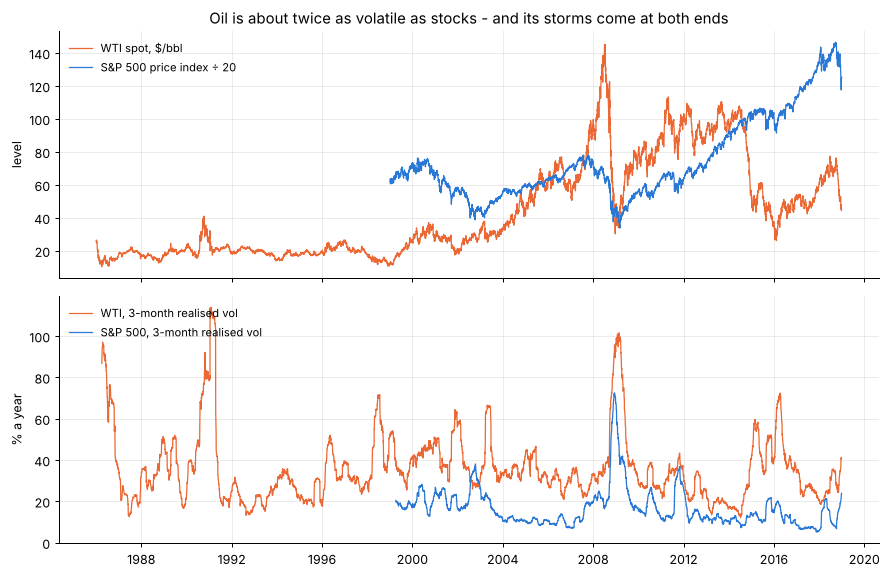

WTI: 8,318 days 1986-01-03 -> 2018-12-28  |  S&P: 5,030 days 1999-01-05 -> 2018-12-31


In [2]:
wti, sp = data.load_wti(), data.load_sp500()
rw, rs = data.log_returns(wti), data.log_returns(sp)
fig, axes = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True)
axes[0].plot(wti.index, wti, color=OIL, lw=1.0, label="WTI spot, $/bbl")
axes[0].plot(sp.index, sp / 20, color=EQ, lw=1.0, label="S&P 500 price index ÷ 20")
axes[0].set_ylabel("level"); axes[0].legend(loc="upper left", fontsize=9, frameon=False)
axes[1].plot(st.realised_vol(rw, 63).index, st.realised_vol(rw, 63) * 100, color=OIL, lw=1.0,
             label="WTI, 3-month realised vol")
axes[1].plot(st.realised_vol(rs, 63).index, st.realised_vol(rs, 63) * 100, color=EQ, lw=1.0,
             label="S&P 500, 3-month realised vol")
axes[1].set_ylabel("% a year"); axes[1].legend(loc="upper left", fontsize=9, frameon=False)
axes[0].set_title("Oil is about twice as volatile as stocks - and its storms come at both ends")
plt.tight_layout(); plt.show()
print(f"WTI: {len(rw):,} days {rw.index[0].date()} -> {rw.index[-1].date()}  |  "
      f"S&P: {len(rs):,} days {rs.index[0].date()} -> {rs.index[-1].date()}")

Look at the oil vol spikes: 1986 (a price *collapse* when Saudi Arabia opened the taps),
1990-91 (a price *spike* when Iraq invaded Kuwait), 2008 and 2014-16 (two *collapses*).
Oil's storms really do come from both directions. The question is which direction wins on
average.

### What happens the month after a big day?

For every day, we look at how loud the *next* month is, and compare days that went up with
days that went down **by the same amount** (big down days are more common, so comparing
like with like matters).

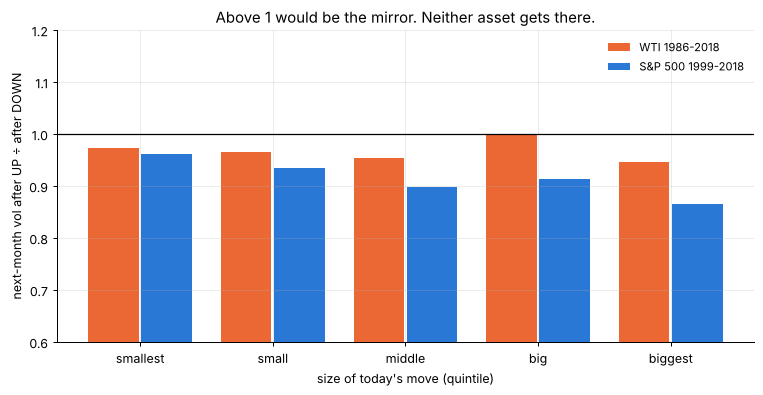

In [3]:
def after_moves(r, h=21, q=5):
    df = pd.DataFrame({"r": r, "fwd": st.forward_vol(r, h)}).dropna()
    df["size"] = pd.qcut(df["r"].abs(), q, labels=False)
    up = df[df.r > 0].groupby("size")["fwd"].mean()
    dn = df[df.r < 0].groupby("size")["fwd"].mean()
    return (up / dn)

fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(5)
ax.bar(x - 0.2, after_moves(rw).values, 0.38, color=OIL, label="WTI 1986-2018")
ax.bar(x + 0.2, after_moves(rs).values, 0.38, color=EQ, label="S&P 500 1999-2018")
ax.axhline(1.0, color="k", lw=1)
ax.set_xticks(x); ax.set_xticklabels(["smallest", "small", "middle", "big", "biggest"])
ax.set_xlabel("size of today's move (quintile)")
ax.set_ylabel("next-month vol after UP ÷ after DOWN")
ax.set_ylim(0.6, 1.2); ax.legend(frameon=False, fontsize=9)
ax.set_title("Above 1 would be the mirror. Neither asset gets there.")
plt.show()

Above the line would mean "rallies are followed by more noise than falls" — the mirror.
The S&P sits clearly below the line, as the textbook says. **Oil also sits below it** — just
closer to 1. After an up day, oil is a little *calmer* than after a down day of the same
size. That's the equity pattern, faintly — not its reflection.

> 🔬 **For the quants:** the formal version is a regression of forward 21-day realised
> vol on today's up-move and down-move separately, controlling for current vol, with
> Newey-West errors. Full-sample WTI: *t*(b_up − b_dn) = **-1.28**; GJR-GARCH inverse *t* = **-2.62** (negative = equity sign).

### Was the mirror ever there? Two eras

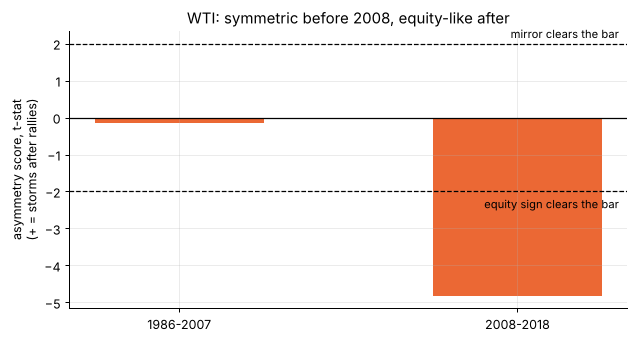

              n  gjr_inv_t   mf_t
era                              
1986-2007  5550     -0.150  0.410
2008-2018  2768     -4.810 -4.650


In [4]:
eras = {"1986-2007": ("1986-01-01", "2007-12-31"), "2008-2018": ("2008-01-01", "2018-12-31")}
tbl = st.era_table(rw, eras)
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(tbl.index, tbl["gjr_inv_t"], color=[OIL, OIL], width=0.5)
ax.axhline(2, color="k", ls="--", lw=1); ax.axhline(-2, color="k", ls="--", lw=1)
ax.axhline(0, color="k", lw=1)
ax.text(1.3, 2.15, "mirror clears the bar", fontsize=9, ha="right")
ax.text(1.3, -2.45, "equity sign clears the bar", fontsize=9, ha="right")
ax.set_ylabel("asymmetry score, t-stat\n(+ = storms after rallies)")
ax.set_title("WTI: symmetric before 2008, equity-like after")
plt.show()
print(tbl[["n", "gjr_inv_t", "mf_t"]].round(2).to_string())

The supply-shock era (1986-2007) is **symmetric** on average — rallies and falls stir up
about the same amount of noise. Then, from 2008, oil starts behaving like a stock: falls
are what make it loud. Something did change — but **away** from the mirror, not toward it.

There *are* stretches where oil looked like the mirror: three-year windows around the 1990-91
Gulf War and the tight-inventory run-up of 1996. That's the grain of truth in the story — a
real supply shock really can make rallies the scary direction, for a while. None of those
windows ends after 1997.

### And the vol-target overlay?

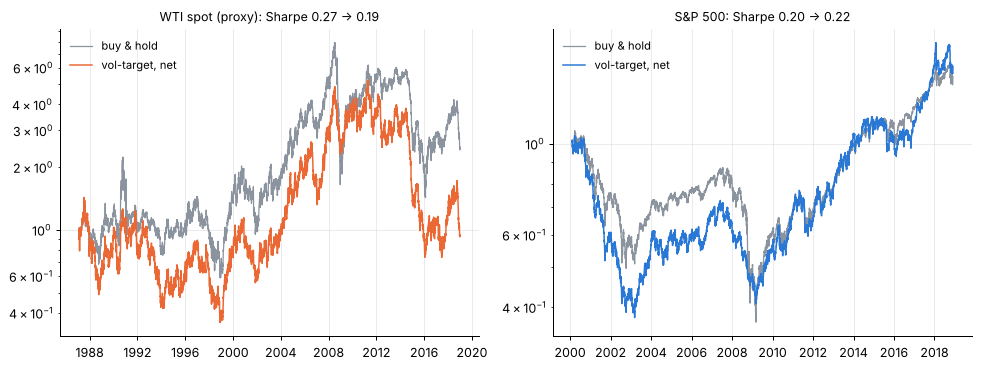

thermostat reaction to last month's return: WTI +0.04, S&P +0.31  (+ = cuts after falls, - = cuts after rallies)


In [5]:
rf = data.load_rf_daily(sp.index)
ow = st.vol_target_overlay(data.simple_returns(wti), None, cost_bps=10, n_boot=200)
os_ = st.vol_target_overlay(data.simple_returns(sp), rf, cost_bps=5, n_boot=200)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, o, c, name in ((axes[0], ow, OIL, "WTI spot (proxy)"), (axes[1], os_, EQ, "S&P 500")):
    s = o["series"]
    ax.plot(np.exp(np.log1p(s["bh"]).cumsum()), color=NULL, lw=1.0, label="buy & hold")
    ax.plot(np.exp(np.log1p(s["net"]).cumsum()), color=c, lw=1.2, label="vol-target, net")
    ax.set_yscale("log"); ax.legend(frameon=False, fontsize=9)
    ax.set_title(f"{name}: Sharpe {o['sharpe_bh']:.2f} -> {o['sharpe_net']:.2f}", fontsize=10)
plt.tight_layout(); plt.show()
print(f"thermostat reaction to last month's return: WTI {ow['react_corr']:+.2f}, "
      f"S&P {os_['react_corr']:+.2f}  (+ = cuts after falls, - = cuts after rallies)")

On stocks the thermostat does what it is famous for: it cuts after falls. On oil it barely
cares which way the price went — it reacts to the *size* of moves, not their direction. It
never cuts after rallies, which is what the mirror would need. And after costs it trails
plain buy-and-hold on the oil tape.

## 5 · The verdict

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Mirror?: Busted](https://img.shields.io/badge/Mirror%3F-Busted-8b949e?style=flat-square)

- **Signal: None.** Neither lens sees the mirror. Oil's asymmetry has the *equity*
  sign over 1986-2018 (GJR *t* = -2.62), weaker than the S&P's
  (-8.10), and it is entirely a post-2008 phenomenon
  (1986-2007 *t* = -0.15; 2008-2018 *t* = -4.81).
- **Tradability: Mirage.** The overlay loses Sharpe on the oil tape after costs, and the
  tape is a spot price no one can hold.
- **Mirror? Busted.** The real story is the opposite of the claim: oil went from symmetric to
  stock-like.

## 6 · Could you trade it?

Not from this tape, for three reasons:

1. **Spot is not a position.** WTI spot is the price of a barrel delivered at Cushing today.
   You'd actually hold futures, rolling them monthly — and the roll yield in oil is large
   enough to dominate long-run returns. Nothing here sees it.
2. **There's no edge to harvest.** The mirror would have changed *how you manage oil risk*,
   not given you a return forecast. It isn't there, so nothing changes: on oil, a vol target
   is just a volatility-sizing rule with no special timing benefit.
3. **The tape stops in 2018.** It never saw April 2020, when the front-month WTI future
   settled below zero — a demand crash that would, if anything, make oil look *more* like a
   stock.

## 7 · Going further 🚪

- **Run it on futures.** A continuous front-month series (with the roll) is the honest
  investable version; the sign question would be the same, the overlay numbers would not.
- **Gold.** The cleanest published case for the inverse effect is gold, which this tape cannot
  test. Our neighbour [993-leverage-effect-asymmetry](../../993-leverage-effect-asymmetry/)
  finds gold close to symmetric.
- **Condition on the shock.** The mirror windows here contain real supply shocks. A test that
  conditions on identified supply vs demand news (rather than on calendar eras) is the natural
  next fork — PRs welcome.